# ------------------------Support Vector Machine --------------------

### Importing Libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

## Working with Perfectly Linear Dataset

In [31]:
from sklearn.datasets import make_classification

# Generate a linearly separable dataset
X, y = make_classification(n_samples=30, n_features=2, n_informative=1, n_redundant=0,
                           n_clusters_per_class=1, flip_y=0, random_state=0)

# X contains the features and y contains the labels (0 or 1)


In [32]:
X

array([[-0.34791215, -0.1313738 ],
       [-1.18063218,  1.23768226],
       [-0.21274028,  0.92539613],
       [-0.63432209,  1.01663965],
       [-1.70627019, -0.87216188],
       [-0.89546656,  1.11384413],
       [ 0.77749036,  1.12133753],
       [-0.30230275, -1.13432894],
       [ 1.20237985, -1.86733036],
       [-0.38732682, -0.15680018],
       [-1.42001794, -0.63559541],
       [-0.50965218, -0.32458194],
       [-0.51080514,  0.07162926],
       [-0.36274117,  0.93193235],
       [-0.67246045,  1.55738075],
       [-1.04855297, -1.09160633],
       [-1.98079647, -0.64486202],
       [ 0.3869025 ,  0.68941611],
       [-0.35955316,  1.5343185 ],
       [-1.61389785,  1.54330781],
       [ 0.06651722,  1.82537493],
       [ 0.42833187,  0.73011867],
       [ 0.3024719 ,  0.4711336 ],
       [-0.02818223,  1.3143441 ],
       [ 1.9507754 ,  0.29066215],
       [-0.4380743 , -0.89201389],
       [ 0.15634897,  0.9887841 ],
       [ 1.23029068,  0.65745054],
       [-0.88778575,

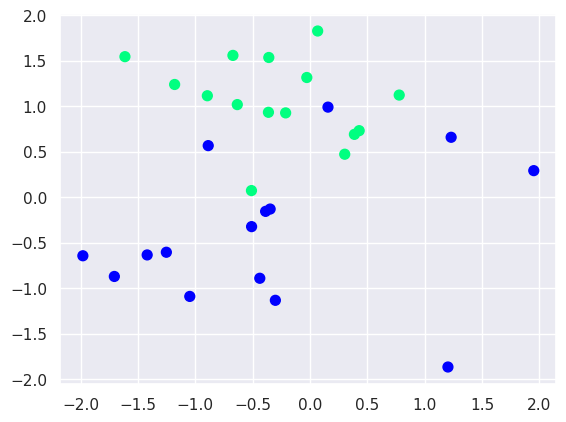

In [33]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

In [34]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1)
model.fit(X, y)

SVC(C=1, kernel='linear')

In [35]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

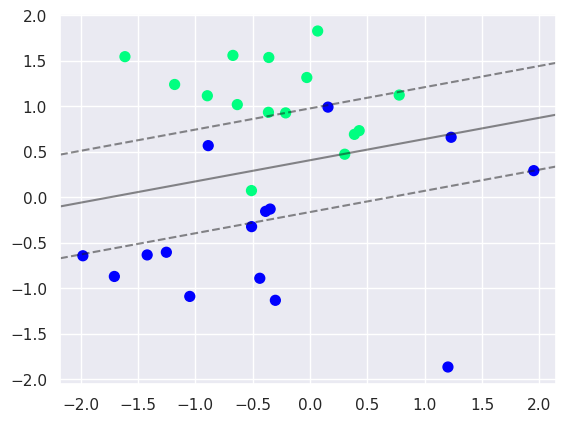

In [36]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

## The importance of Support Vectors

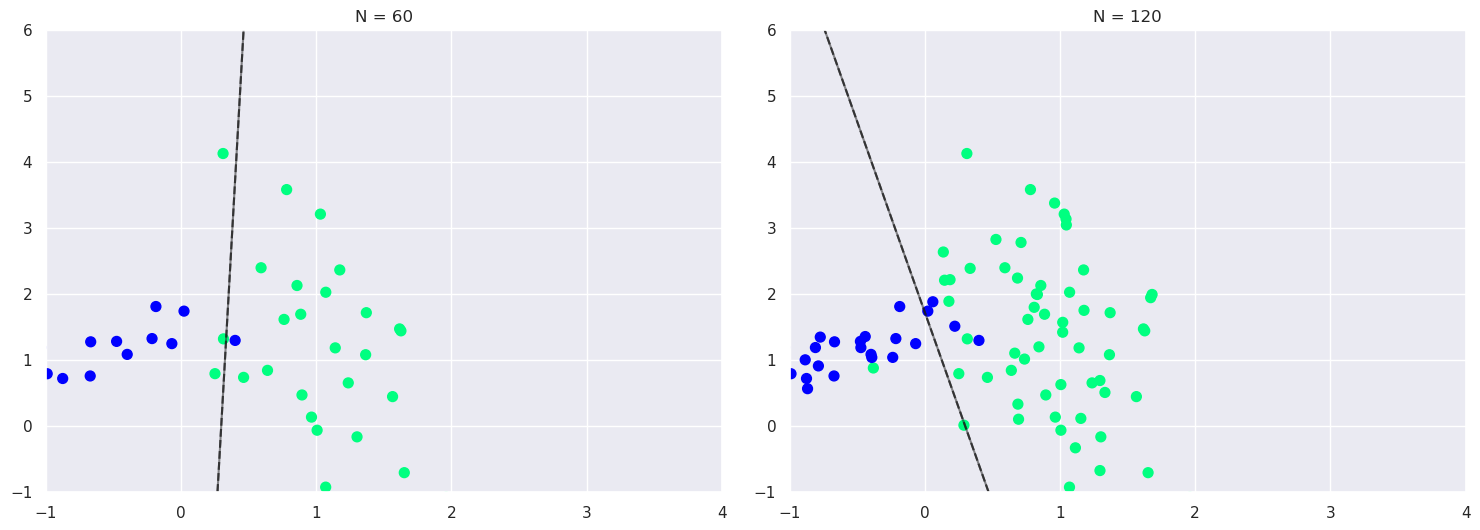

In [37]:
def plot_svm(N=10, ax=None):
    #X, y = make_blobs(n_samples=200, centers=2,
                      #random_state=0, cluster_std=0.60)
    X,y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, flip_y=0, random_state=0)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

## Working with Almost Linearly Separable Dataset

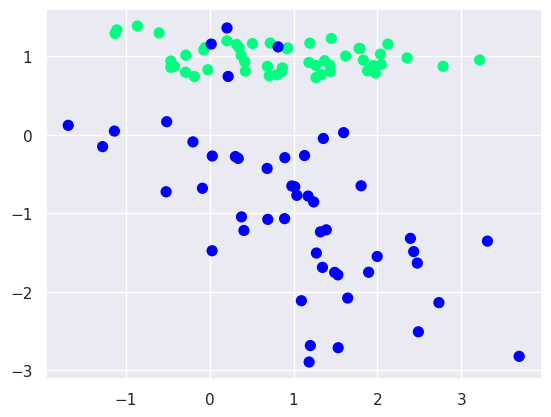

In [38]:
#X, y = make_blobs(n_samples=100, centers=2,
                  #random_state=0, cluster_std=1.2)

from sklearn.datasets import make_classification

# Generate a linearly separable dataset with the specified cluster_std
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, flip_y=0, random_state=0)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

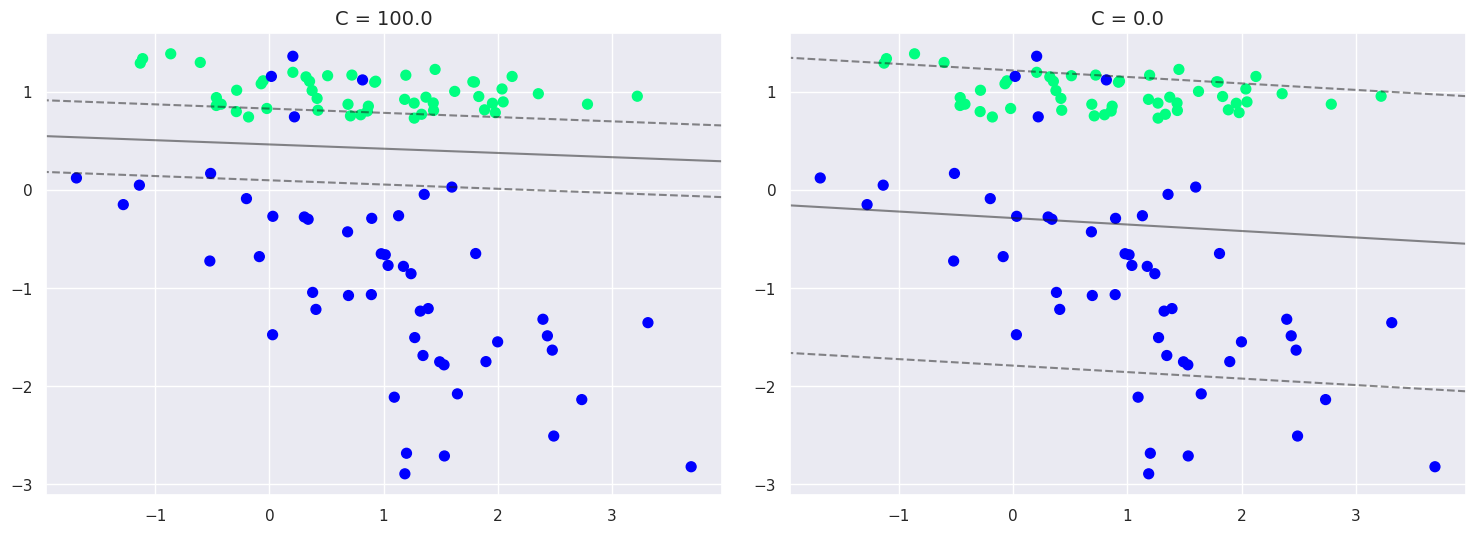

In [39]:
#X, y = make_blobs(n_samples=100, centers=2,
                  #random_state=0, cluster_std=0.8)

X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, flip_y=0, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.01]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)